# 08 — LSTM Sequence Modeling

**Development scope:** Kalimantan only.

## Objective

Notebook 05 established a tabular forecasting benchmark using 20 **Fire History + Weather** features.

This notebook evaluates whether an LSTM can benefit from explicitly representing the **temporal sequence** of those features for each spatial cell.

Two sequence lengths are evaluated:

- **LSTM-14:** previous 14 days
- **LSTM-7:** previous 7 days

The target is the fire-activity state of the **next day**.

### Key distinction from the tabular benchmark

The tabular Logistic Regression model receives engineered lag and rolling features for one cell-day.

The LSTM receives a sequence:

```text
[cell, t-13] ... [cell, t-1] → target at t
```

The spatial cell remains the unit of sequence construction; LSTM does not model interactions between neighboring cells.

> Spatial neighborhood information is evaluated separately in Notebook 06, while ConvLSTM is evaluated separately in Notebook 09.


In [2]:
# 1. Imports and reproducibility

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "karhut_ml_dataset_kalimantan.csv"
RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Run Notebook 04 first."
    )


TensorFlow: 2.21.0
Project root: c:\Users\Asus\Documents\skripsi-karhut
Dataset: c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv


In [3]:
# 2. Load and validate the ML dataset

df = pd.read_csv(DATA_PATH, parse_dates=["date"])

df = (
    df
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Unique cells:", df["cell_id"].nunique())

display(df.head())


Shape: (34272, 29)
Date range: 2026-05-08 → 2026-09-10
Unique cells: 272


,region,cell_id,date,grid_lat,grid_lon,weather_lat,weather_lon,weather_distance_km,fire_count_lag1,fire_count_lag3,...,temperature_max,relative_humidity_mean,precipitation_sum,boundary_layer_height_mean,vapour_pressure_deficit_mean,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,target_fire_active_t1
0,Kalimantan,Kalimantan_-0.75_108.00,2026-05-08,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,28.9,82.750000,47.8,322.083333,0.630833,6.679167,15.0,-3.475577,3.189461,0.0
1,Kalimantan,Kalimantan_-0.75_108.00,2026-05-09,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,29.5,79.916667,6.2,430.416667,0.772500,9.020833,14.5,5.493204,5.629225,0.0
2,Kalimantan,Kalimantan_-0.75_108.00,2026-05-10,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.1,62.500000,0.0,643.125000,1.646667,3.325000,7.1,-0.728517,-0.354466,0.0
3,Kalimantan,Kalimantan_-0.75_108.00,2026-05-11,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,31.2,61.375000,0.0,780.208333,1.700417,7.683333,14.7,-0.473697,-4.136161,0.0
4,Kalimantan,Kalimantan_-0.75_108.00,2026-05-12,-0.75,108.0,-0.75,108.0,0.0,0.0,0.0,...,30.5,70.125000,1.2,545.625000,1.235417,11.966667,20.5,-10.974184,1.647696,0.0


## 3. Define the identical 20 benchmark features

The LSTM uses exactly the same 20 features as Notebook 05.

This is important because the experiment changes the **temporal representation**, not the underlying feature information.


In [4]:
fire_history_features = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

weather_features = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

features_20 = fire_history_features + weather_features
target_col = "target_fire_active_t1"

assert len(features_20) == 20
assert target_col not in features_20

missing = sorted(set(features_20 + [target_col]) - set(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Number of features:", len(features_20))
for i, feature in enumerate(features_20, 1):
    print(f"{i:02d}. {feature}")


Number of features: 20
01. fire_count_lag1
02. fire_count_lag3
03. fire_count_lag7
04. frp_sum_lag1
05. frp_sum_lag3
06. frp_sum_lag7
07. fire_count_roll3
08. fire_count_roll7
09. frp_sum_roll3
10. frp_sum_roll7
11. temperature_mean
12. temperature_max
13. relative_humidity_mean
14. precipitation_sum
15. boundary_layer_height_mean
16. vapour_pressure_deficit_mean
17. wind_speed_mean
18. wind_speed_max
19. wind_u_mean
20. wind_v_mean


## 4. Sequence construction

For a sequence length `L`, each sample is:

```text
X = [features at t-L, ..., features at t-1]
y = target_fire_active_t1 at t
```

The sequence is constructed separately within each `cell_id`.

### Continuity requirement

A sequence must contain **consecutive daily dates**. This prevents the model from treating a gap in observations as if it were a normal one-day interval.


In [5]:
def create_sequences(data, features, target, seq_len):
    X_seq = []
    y_seq = []
    seq_dates = []
    seq_cells = []

    for cell_id, group in data.groupby("cell_id", sort=False):

        group = (
            group
            .sort_values("date")
            .reset_index(drop=True)
        )

        # Validate that this cell has one observation per day.
        date_diffs = group["date"].diff().dropna()

        if not (date_diffs == pd.Timedelta(days=1)).all():
            raise ValueError(
                f"Non-consecutive dates detected for cell_id={cell_id}. "
                "Sequence construction stopped to prevent temporal gaps."
            )

        X_values = group[features].to_numpy(dtype=np.float32)
        y_values = group[target].to_numpy(dtype=np.int8)
        dates = group["date"].to_numpy()

        for i in range(seq_len, len(group)):
            X_seq.append(
                X_values[i-seq_len:i]
            )
            y_seq.append(
                y_values[i]
            )
            seq_dates.append(
                dates[i]
            )
            seq_cells.append(
                cell_id
            )

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.int8),
        np.asarray(seq_dates),
        np.asarray(seq_cells)
    )


## 5. Temporal split helper

Sequences are split according to their **target date**, not according to individual timesteps inside the sequence.

This means a validation sample may legitimately use earlier training-period observations as its historical context. No future observation is used to predict an earlier target.


In [6]:
def split_sequences(X, y, dates, train_end="2026-08-01", test_start="2026-09-01"):
    train_mask = dates < np.datetime64(train_end)

    val_mask = (
        (dates >= np.datetime64(train_end)) &
        (dates < np.datetime64(test_start))
    )

    test_mask = dates >= np.datetime64(test_start)

    return {
        "train": (X[train_mask], y[train_mask]),
        "val": (X[val_mask], y[val_mask]),
        "test": (X[test_mask], y[test_mask]),
        "train_dates": dates[train_mask],
        "val_dates": dates[val_mask],
        "test_dates": dates[test_mask],
        "train_cells": None,
        "val_cells": None,
        "test_cells": None
    }


## 6. Standardization without leakage

LSTM training is performed on standardized features.

The scaler is fitted **only on the training sequence observations** and then applied unchanged to validation and test.

Because sequences contain repeated cell-days across overlapping windows, the scaler is fitted over the flattened training timesteps. This uses no validation or test values.


In [7]:
def scale_sequence_data(X_train, X_val, X_test):
    n_features = X_train.shape[-1]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, n_features)
    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(
        X_train_2d
    ).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    X_test_scaled = scaler.transform(
        X_test.reshape(-1, n_features)
    ).reshape(X_test.shape)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


## 7. Class weights

The target distribution changes substantially across time.

Class weights are therefore calculated from the **training targets only** for each sequence experiment and passed to Keras during fitting.


In [8]:
def get_class_weights(y_train):
    classes = np.array([0, 1])

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )

    return {
        0: float(weights[0]),
        1: float(weights[1])
    }


## 8. Model definition

Architecture used for both sequence lengths:

```text
LSTM(64)
↓
Dropout(0.30)
↓
Dense(32, ReLU)
↓
Dropout(0.20)
↓
Dense(1, Sigmoid)
```

The only controlled change between LSTM-14 and LSTM-7 is the sequence length.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(
            64,
            input_shape=(seq_len, n_features)
        ),
        Dropout(0.30),
        Dense(32, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy"
    )

    return model


## 9. Evaluation helper

PR-AUC is the primary metric.

Threshold-based metrics are reported at an operating threshold selected from the validation set only.


In [10]:
def evaluate_probabilities(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Threshold": threshold
    }


def select_f1_threshold(y_true, y_prob, start=0.30, stop=0.81, step=0.01):
    rows = []

    for threshold in np.arange(start, stop, step):
        threshold = round(float(threshold), 2)
        pred = (y_prob >= threshold).astype(int)

        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["F1", "Recall", "Threshold"],
            ascending=[False, False, True]
        )
        .reset_index(drop=True)
    )


# 10. Reusable LSTM experiment function

This function keeps the LSTM-14 and LSTM-7 experiments identical except for sequence length.


In [11]:
def run_lstm_experiment(data, seq_len):
    X_seq, y_seq, seq_dates, seq_cells = create_sequences(
        data,
        features_20,
        target_col,
        seq_len
    )

    train_mask = seq_dates < np.datetime64("2026-08-01")

    val_mask = (
        (seq_dates >= np.datetime64("2026-08-01")) &
        (seq_dates < np.datetime64("2026-09-01"))
    )

    test_mask = seq_dates >= np.datetime64("2026-09-01")

    X_train = X_seq[train_mask]
    y_train = y_seq[train_mask]

    X_val = X_seq[val_mask]
    y_val = y_seq[val_mask]

    X_test = X_seq[test_mask]
    y_test = y_seq[test_mask]

    train_dates = seq_dates[train_mask]
    val_dates = seq_dates[val_mask]
    test_dates = seq_dates[test_mask]

    X_train, X_val, X_test, scaler = scale_sequence_data(
        X_train,
        X_val,
        X_test
    )

    class_weights = get_class_weights(y_train)

    model = build_lstm(
        seq_len=seq_len,
        n_features=len(features_20)
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )

    val_prob = model.predict(X_val, verbose=0).ravel()
    test_prob = model.predict(X_test, verbose=0).ravel()

    threshold_table = select_f1_threshold(
        y_val,
        val_prob
    )

    threshold = float(
        threshold_table.iloc[0]["Threshold"]
    )

    val_metrics = evaluate_probabilities(
        y_val,
        val_prob,
        threshold
    )

    test_metrics = evaluate_probabilities(
        y_test,
        test_prob,
        threshold
    )

    test_cm = confusion_matrix(
        y_test,
        (test_prob >= threshold).astype(int)
    )

    return {
        "seq_len": seq_len,
        "X_shape": X_seq.shape,
        "y_shape": y_seq.shape,
        "train_shape": X_train.shape,
        "val_shape": X_val.shape,
        "test_shape": X_test.shape,
        "train_positive_rate": float(y_train.mean()),
        "val_positive_rate": float(y_val.mean()),
        "test_positive_rate": float(y_test.mean()),
        "model": model,
        "history": history,
        "scaler": scaler,
        "class_weights": class_weights,
        "val_prob": val_prob,
        "test_prob": test_prob,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "test_cm": test_cm,
        "threshold_table": threshold_table,
        "train_dates": train_dates,
        "val_dates": val_dates,
        "test_dates": test_dates,
        "train_cells": seq_cells[train_mask],
        "val_cells": seq_cells[val_mask],
        "test_cells": seq_cells[test_mask]
    }


## 11. Experiment A — LSTM-14

The first sequence contains the previous **14 daily observations** for the same spatial cell.

Target:

```text
fire activity at the next day
```


In [12]:
lstm14 = run_lstm_experiment(
    df,
    seq_len=14
)

print("Sequence shape:", lstm14["X_shape"])
print("Train shape:", lstm14["train_shape"])
print("Validation shape:", lstm14["val_shape"])
print("Test shape:", lstm14["test_shape"])

print("\nPositive rates:")
print("Train:", lstm14["train_positive_rate"])
print("Validation:", lstm14["val_positive_rate"])
print("Test:", lstm14["test_positive_rate"])

print("\nSelected threshold:", lstm14["val_metrics"]["Threshold"])

print("\nValidation metrics:")
for k, v in lstm14["val_metrics"].items():
    print(f"{k:10s}: {v:.6f}")

print("\nTest metrics:")
for k, v in lstm14["test_metrics"].items():
    print(f"{k:10s}: {v:.6f}")

print("\nTest confusion matrix:")
print(lstm14["test_cm"])


c:\Users\Asus\Documents\skripsi-karhut\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.4610 - val_loss: 0.3533
Epoch 2/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4255 - val_loss: 0.3603
Epoch 3/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4210 - val_loss: 0.3605
Epoch 4/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4134 - val_loss: 0.3632
Epoch 5/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4075 - val_loss: 0.3726
Epoch 6/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3988 - val_loss: 0.3749
Epoch 7/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3945 - val_loss: 0.3795
Epoch 8/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3858 - val_loss: 0.3885
Sequence shape: (30464, 14, 20)
Train shape: (19312, 14, 20)
Validation shape: (8432, 14, 20)
Test shape: (2720, 14, 20)

Positive rates:
Train: 0.118993371996686
Validation: 0.3391840607210626
Test: 0.31948529411764703

Selected threshold: 0.71

Validation metrics:
PR-AUC    : 0.905304
Precision : 0.748404
Rec

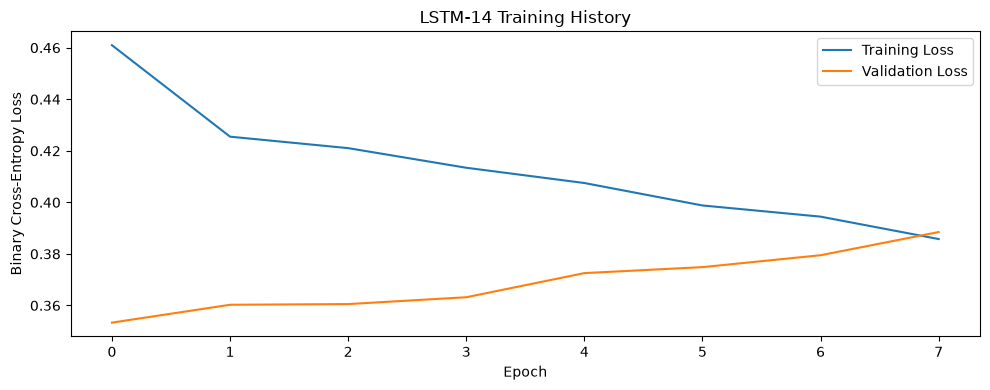

In [13]:
# 12. LSTM-14 learning curves

history14 = lstm14["history"].history

plt.figure(figsize=(10, 4))
plt.plot(history14["loss"], label="Training Loss")
plt.plot(history14["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("LSTM-14 Training History")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Experiment B — LSTM-7

The second sequence uses the previous **7 daily observations**.

All other settings remain unchanged.


In [14]:
lstm7 = run_lstm_experiment(
    df,
    seq_len=7
)

print("Sequence shape:", lstm7["X_shape"])
print("Train shape:", lstm7["train_shape"])
print("Validation shape:", lstm7["val_shape"])
print("Test shape:", lstm7["test_shape"])

print("\nPositive rates:")
print("Train:", lstm7["train_positive_rate"])
print("Validation:", lstm7["val_positive_rate"])
print("Test:", lstm7["test_positive_rate"])

print("\nSelected threshold:", lstm7["val_metrics"]["Threshold"])

print("\nValidation metrics:")
for k, v in lstm7["val_metrics"].items():
    print(f"{k:10s}: {v:.6f}")

print("\nTest metrics:")
for k, v in lstm7["test_metrics"].items():
    print(f"{k:10s}: {v:.6f}")

print("\nTest confusion matrix:")
print(lstm7["test_cm"])


Epoch 1/50


c:\Users\Asus\Documents\skripsi-karhut\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4724 - val_loss: 0.4110
Epoch 2/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4328 - val_loss: 0.4030
Epoch 3/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4259 - val_loss: 0.4156
Epoch 4/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4196 - val_loss: 0.4007
Epoch 5/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4153 - val_loss: 0.3948
Epoch 6/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4133 - val_loss: 0.4074
Epoch 7/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4057 - val_loss: 0.3870
Epoch 8/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4058 - val_loss: 0.3927
Epoch 9/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4022 - val_loss: 0.3800
Epoch 10/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3959 - val_loss: 0.3893
Epoch 11/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3952 - val_loss: 0.3858
Epoch 12/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.

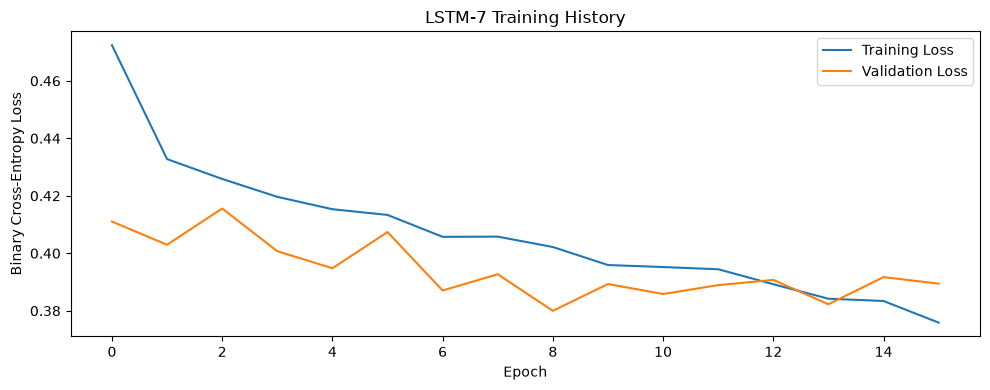

In [15]:
# 14. LSTM-7 learning curves

history7 = lstm7["history"].history

plt.figure(figsize=(10, 4))
plt.plot(history7["loss"], label="Training Loss")
plt.plot(history7["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("LSTM-7 Training History")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Compare LSTM-7 and LSTM-14

This comparison addresses whether the length of the historical sequence changes performance under the same architecture and feature set.


In [16]:
lstm_validation_results = pd.DataFrame([
    {
        "Model": "LSTM-14",
        **lstm14["val_metrics"]
    },
    {
        "Model": "LSTM-7",
        **lstm7["val_metrics"]
    }
])

lstm_test_results = pd.DataFrame([
    {
        "Model": "LSTM-14",
        **lstm14["test_metrics"]
    },
    {
        "Model": "LSTM-7",
        **lstm7["test_metrics"]
    }
])

print("Validation:")
display(lstm_validation_results)

print("Test:")
display(lstm_test_results)


Validation:


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,LSTM-14,0.905304,0.748404,0.901748,0.817951,0.863852,0.71
1,LSTM-7,0.885433,0.753286,0.861538,0.803784,0.857329,0.70


Test:


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold
0,LSTM-14,0.902548,0.667480,0.944764,0.782277,0.831985,0.71
1,LSTM-7,0.897341,0.686258,0.913694,0.783810,0.838971,0.70


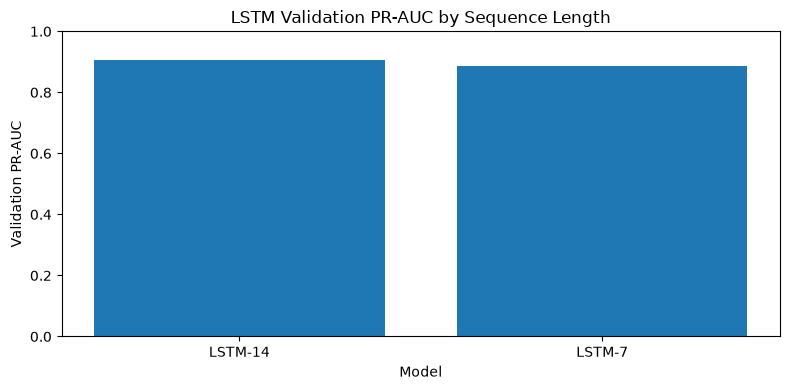

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(
    lstm_validation_results["Model"],
    lstm_validation_results["PR-AUC"]
)
plt.xlabel("Model")
plt.ylabel("Validation PR-AUC")
plt.title("LSTM Validation PR-AUC by Sequence Length")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 16. Comparison with the established tabular benchmark

The main tabular benchmark remains owned by Notebook 05.

The LSTM results are interpreted as an **alternative temporal representation experiment**, not as a replacement of the benchmark simply because it uses a more complex architecture.

If the LSTM does not improve validation PR-AUC over the established 20-feature Logistic Regression benchmark, the result indicates that explicit sequence modeling did not add predictive value under this particular representation and dataset.


In [18]:
benchmark_path = RESULTS_DIR / "benchmark_validation_results.csv"

if benchmark_path.exists():
    benchmark_results = pd.read_csv(benchmark_path)

    lr_rows = benchmark_results[
        benchmark_results["Model"].str.contains(
            "Logistic Regression",
            case=False,
            regex=False
        )
    ]

    if not lr_rows.empty:
        lr_prauc = float(lr_rows.iloc[0]["PR-AUC"])

        comparison = lstm_validation_results[[
            "Model", "PR-AUC", "Precision", "Recall", "F1", "Accuracy", "Threshold"
        ]].copy()

        comparison["Delta_vs_LR"] = comparison["PR-AUC"] - lr_prauc

        print(f"Established Logistic Regression validation PR-AUC: {lr_prauc:.6f}")
        display(comparison)
    else:
        print("Logistic Regression row not found in Notebook 05 benchmark output.")
else:
    print("Notebook 05 benchmark output not found.")


Established Logistic Regression validation PR-AUC: 0.901149


,Model,PR-AUC,Precision,Recall,F1,Accuracy,Threshold,Delta_vs_LR
0,LSTM-14,0.905304,0.748404,0.901748,0.817951,0.863852,0.71,0.004156
1,LSTM-7,0.885433,0.753286,0.861538,0.803784,0.857329,0.70,-0.015716


## 17. Sequence-level sanity checks

These checks document that:

- the sequence target dates fall in the intended temporal periods;
- no sequence crosses a missing daily observation;
- train/validation/test samples are assigned by target date;
- the number of features remains 20.


In [19]:
sequence_sanity = pd.DataFrame([
    {
        "Model": "LSTM-14",
        "Sequence Length": 14,
        "Total Sequences": lstm14["X_shape"][0],
        "Timesteps": lstm14["X_shape"][1],
        "Features": lstm14["X_shape"][2],
        "First Target Date": pd.Timestamp(lstm14["train_dates"].min()).date(),
        "Last Test Target Date": pd.Timestamp(lstm14["test_dates"].max()).date()
    },
    {
        "Model": "LSTM-7",
        "Sequence Length": 7,
        "Total Sequences": lstm7["X_shape"][0],
        "Timesteps": lstm7["X_shape"][1],
        "Features": lstm7["X_shape"][2],
        "First Target Date": pd.Timestamp(lstm7["train_dates"].min()).date(),
        "Last Test Target Date": pd.Timestamp(lstm7["test_dates"].max()).date()
    }
])

display(sequence_sanity)


,Model,Sequence Length,Total Sequences,Timesteps,Features,First Target Date,Last Test Target Date
0,LSTM-14,14,30464,14,20,2026-05-22,2026-09-10
1,LSTM-7,7,32368,7,20,2026-05-15,2026-09-10


## 18. Save LSTM experiment outputs

Saved outputs:

```text
data/processed/model_results/
├── lstm_validation_results.csv
├── lstm_test_results.csv
└── lstm_sequence_summary.csv
```

Model weights are not saved here because the notebook is intended as a reproducible research experiment. If deployment or later inference is required, model serialization can be added separately.


In [20]:
lstm_validation_output = RESULTS_DIR / "lstm_validation_results.csv"
lstm_test_output = RESULTS_DIR / "lstm_test_results.csv"
lstm_summary_output = RESULTS_DIR / "lstm_sequence_summary.csv"

lstm_validation_results.to_csv(
    lstm_validation_output,
    index=False
)

lstm_test_results.to_csv(
    lstm_test_output,
    index=False
)

sequence_sanity.to_csv(
    lstm_summary_output,
    index=False
)

print("Saved:")
print(" -", lstm_validation_output)
print(" -", lstm_test_output)
print(" -", lstm_summary_output)


Saved:
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lstm_validation_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lstm_test_results.csv
 - c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\lstm_sequence_summary.csv


# Notebook 08 — Conclusion

This notebook evaluates explicit temporal sequence modeling using LSTM while preserving the same 20 Fire History + Weather features used by the tabular benchmark.

### Experiments

- **LSTM-14:** 14-day historical sequence
- **LSTM-7:** 7-day historical sequence

### Methodological controls

- Same Kalimantan development dataset as Notebook 05.
- Same target.
- Same temporal train/validation/test boundaries.
- Standardization fitted on training data only.
- Class weights calculated from training targets only.
- Early stopping uses validation loss.
- Operating threshold is selected from validation only.
- Test data are not used during model selection.

The experiment therefore isolates the effect of representing the historical feature information as a sequence rather than as a single tabular vector.

The results should be interpreted as evidence for this specific dataset, feature representation, sequence length, and training protocol. They do not establish that LSTM is generally better or worse than simpler models.
